# **Project: Hate Speech Detection using Transformers (Deep Learning)**

**Problem Statement:**

The term hate speech is understood as any type of verbal, written or behavioural communication that attacks or uses derogatory or discriminatory language against a person or group based on what they are, in other words, based on their religion, ethnicity, nationality, race, colour, ancestry, sex or another identity factor. In this problem, We will take you through a hate speech detection model with Machine Learning and Python.

Hate Speech Detection is generally a task of sentiment classification. So for training, a model that can classify hate speech from a certain piece of text can be achieved by training it on a data that is generally used to classify sentiments. So for the task of hate speech detection model, We will use the Twitter tweets to identify tweets containing  Hate speech.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Importing Dataset

In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/drive/MyDrive/Final Project/train_E6oV3lV.csv')
df.head(10)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before the...
6,7,0,@user camping tomorrow @user @user @user @use...
7,8,0,the next school year is the year for exams.ð...
8,9,0,we won!!! love the land!!! #allin #cavs #champ...
9,10,0,@user @user welcome here ! i'm it's so #gr...


## 2. Data understanding

### 2.1 Number of Observations and Features

In [ ]:
print(f'Number of Observations: {df.shape[0]}')
print(f'Number of Features: {df.shape[1]}')

Number of Observations: 31962
Number of Features: 3


### 2.2 Features in the Dataset

In [ ]:
df.columns

Index(['id', 'label', 'tweet'], dtype='object')

### 2.3 Data Types for Each Column

In [ ]:
df.dtypes

,0
id,int64
label,int64
tweet,object


### 2.4 Data Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


### 2.5 Dataset Size

In [ ]:
df.size

95886

### 2.6 Predictor and Target Variable

In [ ]:
# Predictor
predictor = df[['tweet']]
predictor.tail()




,tweet
31957,ate @user isz that youuu?ðððððð...
31958,to see nina turner on the airwaves trying to...
31959,listening to sad songs on a monday morning otw...
31960,"@user #sikh #temple vandalised in in #calgary,..."
31961,thank you @user for you follow


In [ ]:
# Target
target = df[['label']]
target.tail()

,label
31957,0
31958,0
31959,0
31960,1
31961,0


### 2.7 Missing Values Check



In [ ]:
df.isnull().sum()

,0
id,0
label,0
tweet,0


### 2.8 Checking Duplicate Values

In [ ]:
df.duplicated().sum()

0

### 2.9 Class Distribution and Pie Chart

Hate Speech = 2242
Free Speech = 29720


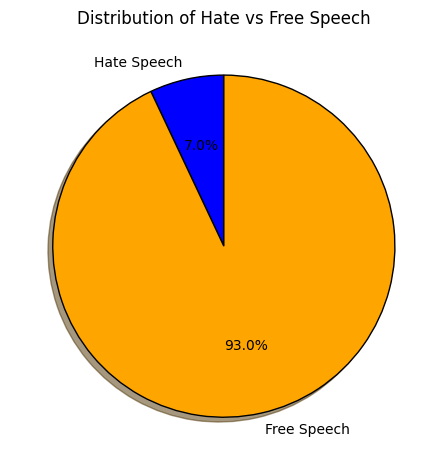

In [ ]:
hate_speech = df[df['label'] == 1].shape[0]
free_speech = df[df['label'] == 0].shape[0]

print('Hate Speech =', hate_speech)
print('Free Speech =', free_speech)

# Visualization
import matplotlib.pyplot as plt

speech = [hate_speech, free_speech]
label_names = ["Hate Speech", "Free Speech"]

plt.pie(speech, labels=label_names, shadow=True, wedgeprops={'edgecolor': 'black'},
        autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])

plt.title('Distribution of Hate vs Free Speech')
plt.tight_layout()
plt.show()


### 2.10 Outlier Detection (Text Length-Based)

count    31962.000000
mean        84.739628
std         29.455749
min         11.000000
25%         63.000000
50%         88.000000
75%        108.000000
max        274.000000
Name: text_length, dtype: float64


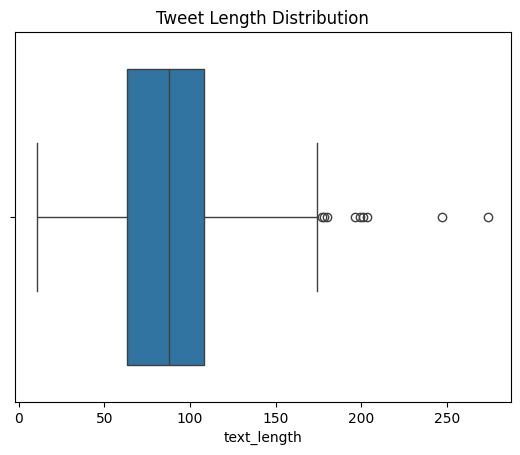

Upper Outlier Threshold: 138.0
Lower Outlier Threshold: 21.0


In [ ]:
df['text_length'] = df['tweet'].apply(len)

# Descriptive stats
print(df['text_length'].describe())

# Outliers: Very long or very short tweets
import seaborn as sns
sns.boxplot(x=df['text_length'])
plt.title("Tweet Length Distribution")
plt.show()

# Thresholds for outliers
upper_threshold = df['text_length'].quantile(0.99)
lower_threshold = df['text_length'].quantile(0.01)

print(f"Upper Outlier Threshold: {upper_threshold}")
print(f"Lower Outlier Threshold: {lower_threshold}")


### 2.11 Skewness in Tweet Length

In [ ]:
print(f"Skewness in tweet length: {df['text_length'].skew()}")


Skewness in tweet length: -0.22923564654998468


## 3. Data Preprocessing

In the data preprocessing phase, we cleaned the tweets to ensure the text is consistent and noise-free before feature extraction. We applied the following operations:

1.  Convert all characters to lowercase for uniformity.
2.  Remove User Mentions: Twitter handles (e.g., @user) were removed as they don't add semantic value.
3. Remove URLs: URLs were removed to avoid noise.
4. Remove Special Characters & Digits: Only alphabetic characters were retained.
5. Strip Whitespace: Removed leading and trailing spaces.






### 3.1 Text Cleaning

#### 3.1.1 Lowercasing

In [ ]:
import re

In [ ]:
def to_lowercase(text):
    return text.lower()

df['tweet'] = df['tweet'].apply(to_lowercase)
df.head()


,id,label,tweet,text_length
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


#### 3.1.2 Remove User Mentions (@tags)

In [ ]:
def remove_mentions(text):
    return re.sub(r'@[\w]*', '', text)

df['tweet'] = df['tweet'].apply(remove_mentions)
df.head()


,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for #lyft credit i can't use cause th...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


####  3.1.3 Remove URLs

In [ ]:
def remove_urls(text):
    return re.sub(r'http\S+', '', text)

df['tweet'] = df['tweet'].apply(remove_urls)
df.head()

,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for #lyft credit i can't use cause th...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


#### 3.1.4 Remove Special Characters and Digits

In [ ]:
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters and whitespace

df['tweet'] = df['tweet'].apply(remove_special_chars)
df.head()

,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for lyft credit i cant use cause they...,122
2,3,0,bihday your majesty,21
3,4,0,model i love u take with u all the time in u...,86
4,5,0,factsguide society now motivation,39


#### 3.1.5 Strip Leading and Trailing Whitespace

In [ ]:
def strip_whitespace(text):
    return text.strip()

df['tweet'] = df['tweet'].apply(strip_whitespace)
df.head()


,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so selfi...,102
1,2,0,thanks for lyft credit i cant use cause they d...,122
2,3,0,bihday your majesty,21
3,4,0,model i love u take with u all the time in ur,86
4,5,0,factsguide society now motivation,39


In [ ]:
import shutil

# Force-delete the possibly corrupted punkt folder
shutil.rmtree('/root/nltk_data/tokenizers/punkt', ignore_errors=True)


### 3.2 Remove Stopwords

Stopwords are commonly used words in a language (such as "and", "the", "is", etc.) that do not carry significant meaning in natural language processing tasks. Removing stopwords helps in reducing noise and dimensionality of the text data.


In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['tweet'] = df['tweet'].apply(remove_stopwords)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,label,tweet,text_length
0,1,0,father dysfunctional selfish drags kids dysfun...,102
1,2,0,thanks lyft credit cant use cause dont offer w...,122
2,3,0,bihday majesty,21
3,4,0,model love u take u time ur,86
4,5,0,factsguide society motivation,39


### 3.3 Tokenization

Tokenization is the process of splitting text into individual units such as words or terms, which are called tokens. This step is essential for most NLP tasks, including text classification, feature extraction, and semantic analysis.


In [ ]:
import nltk
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Import the tokenizer
from nltk.tokenize import word_tokenize

# Apply tokenization
df['tokens'] = df['tweet'].astype(str).apply(word_tokenize)

# Display the result
print(df[['tweet', 'tokens']].head())


                                               tweet  \
0  father dysfunctional selfish drags kids dysfun...   
1  thanks lyft credit cant use cause dont offer w...   
2                                     bihday majesty   
3                        model love u take u time ur   
4                      factsguide society motivation   

                                              tokens  
0  [father, dysfunctional, selfish, drags, kids, ...  
1  [thanks, lyft, credit, cant, use, cause, dont,...  
2                                  [bihday, majesty]  
3                [model, love, u, take, u, time, ur]  
4                  [factsguide, society, motivation]  


### 3.4 Lemmatization

Lemmatization reduces words to their base or root form using linguistic knowledge. Unlike stemming, lemmatization ensures that the reduced word is a valid word. This helps in grouping different forms of a word to a single term, improving the model's understanding of the semantics.


In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)
df[['tweet', 'lemmatized_tokens']].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tweet,lemmatized_tokens
0,father dysfunctional selfish drags kids dysfun...,"[father, dysfunctional, selfish, drag, kid, dy..."
1,thanks lyft credit cant use cause dont offer w...,"[thanks, lyft, credit, cant, use, cause, dont,..."
2,bihday majesty,"[bihday, majesty]"
3,model love u take u time ur,"[model, love, u, take, u, time, ur]"
4,factsguide society motivation,"[factsguide, society, motivation]"


##  4. Featurization Techniques


 ### 4.1 Bag of Words (BoW)

Bag of Words (BoW) is a simple vectorization technique that counts how many times each word occurs in a document. It ignores grammar and word order. Each unique word is assigned a feature index, and the value is the frequency of that word in the document.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
# Combine lemmatized tokens into single cleaned sentence
df['text_cleaned'] = df['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))



In [ ]:
# Initialize CountVectorizer
vectorizer_bow = CountVectorizer()

# Fit and transform
X_bow = vectorizer_bow.fit_transform(df['text_cleaned'])

# Convert to array
X_bow_array = X_bow.toarray()


In [ ]:
# Vocabulary words
print("Total features (unique words):", len(vectorizer_bow.get_feature_names_out()))
print("First 10 features:", vectorizer_bow.get_feature_names_out()[:10])

# BoW representation for the first sample
print("Shape of BoW matrix:", X_bow_array.shape)
print("First Ten document vector:", X_bow_array[:10])



Total features (unique words): 37215
First 10 features: ['aa' 'aaa' 'aaaaa' 'aaaaaand' 'aaaaah' 'aaaaand' 'aaahh' 'aaahhhh'
 'aaahhhhh' 'aaand']
Shape of BoW matrix: (31962, 37215)
First Ten document vector: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


### 4.2 TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF (Term Frequency–Inverse Document Frequency) is a statistical measure
which is used to evaluate the importance of a word in a document relative to a collection (corpus) of documents.

It combines two metrics:
- Term Frequency (TF): how frequently a term occurs in a document.
- Inverse Document Frequency (IDF): how rare a term is across all documents.

The idea is to reduce the weight of common words (like "the", "is") and boost rare but meaningful words.
TF-IDF helps in improving text representation for classification or clustering by focusing on informative words.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer (you can also specify max_features if needed)
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_tfidf = tfidf_vectorizer.fit_transform(df['text_cleaned'])

# Convert to array for inspection
X_tfidf_array = X_tfidf.toarray()

# Show some info
print("TF-IDF Matrix Shape:", X_tfidf_array.shape)
print("First 10 TF-IDF Features:", tfidf_vectorizer.get_feature_names_out()[:10])
print("First Ten Document TF-IDF Vector:", X_tfidf_array[:10])


TF-IDF Matrix Shape: (31962, 37215)
First 10 TF-IDF Features: ['aa' 'aaa' 'aaaaa' 'aaaaaand' 'aaaaah' 'aaaaand' 'aaahh' 'aaahhhh'
 'aaahhhhh' 'aaand']
First Ten Document TF-IDF Vector: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### 4.3 Word Embeddings

Word Embeddings represent words as dense vectors in a continuous vector space,
 where semantically similar words are closer together.
Unlike BoW or TF-IDF which produce sparse high-dimensional vectors,
embeddings capture contextual similarity and meaning of words.
Pre-trained embeddings like Word2Vec or GloVe are commonly used for better generalization.
In this step, we will use the Gensim library to load pre-trained GloVe embeddings
 and generate average embeddings for each document.


In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

In [ ]:
import numpy as np
import gensim.downloader as api
from tqdm import tqdm

# Load GloVe vectors (100-dimensional)
glove_vectors = api.load("glove-wiki-gigaword-100")

# Function to get average embedding for each document
def get_average_embedding(tokens, model, dim=100):
    valid_tokens = [token for token in tokens if token in model]
    if not valid_tokens:
        return np.zeros(dim)
    return np.mean([model[token] for token in valid_tokens], axis=0)

# Apply to all lemmatized tokenized tweets
document_embeddings = []
for tokens in tqdm(df['lemmatized_tokens']):
    document_embeddings.append(get_average_embedding(tokens, glove_vectors))

# Convert to numpy array
X_embeddings = np.array(document_embeddings)

# Output shape and example
print("Word Embedding Shape:", X_embeddings.shape)
print("First Ten document embedding vector:", X_embeddings[:10])


100%|██████████| 31962/31962 [00:01<00:00, 27003.19it/s]

Word Embedding Shape: (31962, 100)
First Ten document embedding vector: [[ 3.06581587e-01 -1.68644134e-02  4.57118988e-01 -4.09222275e-01
  -3.85742843e-01  5.46751440e-01 -2.05153421e-01  5.76934293e-02
   1.11832872e-01 -1.69032868e-02 -2.29982853e-01  1.68261290e-01
   1.88851997e-01 -1.07607715e-01  1.23908572e-01  8.58917236e-02
  -1.09901428e-01  1.58867002e-01  9.28398743e-02  5.14975727e-01
   2.03575566e-01 -1.34814298e-02  4.40199971e-02 -1.49220720e-01
   2.31208563e-01  1.54868856e-01 -4.96378571e-01 -5.41889846e-01
   1.36520565e-01  3.06937188e-01  1.72679707e-01  5.50997198e-01
   2.43241295e-01 -1.90060273e-01 -1.76499590e-01  1.08832851e-01
  -1.81032151e-01  1.87240005e-01  1.95029989e-01 -5.20029245e-03
   7.14462847e-02  1.41155571e-01 -1.62123844e-01 -3.14392716e-01
  -2.99022734e-01  1.15441278e-01  1.08840145e-01  1.59997597e-01
  -3.00535727e-02 -4.09180015e-01 -4.72636878e-01 -2.12386280e-01
   1.50951415e-01  5.08315682e-01  1.70710400e-01 -1.24689567e+00
  -1

### 4.4 BERT
4.4 BERT (Bidirectional Encoder Representations from Transformers)

BERT is a powerful language model developed by Google. It generates contextualized word embeddings by considering the full sentence (both left and right context), unlike traditional embeddings such as Word2Vec or GloVe.

In this step, we'll use the `bert-base-uncased` model from HuggingFace Transformers to extract embeddings for each tweet.
These embeddings are useful for downstream NLP tasks such as sentiment analysis, classification, or clustering.

Due to computational constraints, we will compute a single fixed-size vector for each tweet by averaging the token embeddings (excluding special tokens).
"""


In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from tqdm import tqdm

# Load BERT only once
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def extract_bert_features(text_series):
    features = []

    for text in tqdm(text_series.astype(str), desc="Extracting BERT embeddings"):
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            outputs = model(**inputs)
        # Use the [CLS] token's embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        features.append(cls_embedding)

    return np.array(features)



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Apply BERT feature extraction
bert_features = extract_bert_features(df['text_cleaned'])
print("BERT features shape:", bert_features.shape)



Extracting BERT embeddings: 100%|██████████| 31962/31962 [1:03:27<00:00,  8.39it/s]


BERT features shape: (31962, 768)


In [ ]:
# Save as .npy for later use in ML models or fine-tuning
np.save("bert_features.npy", bert_features)


In [ ]:
import pandas as pd
import numpy as np

# Example: Saving BERT features
np.save('bert_features.npy', bert_features)

# Saving TF-IDF (if it's a sparse matrix)
import scipy.sparse
scipy.sparse.save_npz("tfidf_features.npz", X_tfidf)

# Saving GloVe and BoW
np.save('glove_features.npy', X_bow_array)
np.save('bow_features.npy', X_bow_array)


## 5. EDA (Exploratory Data Analysis)

### 5.1 Number of Words per Tweet


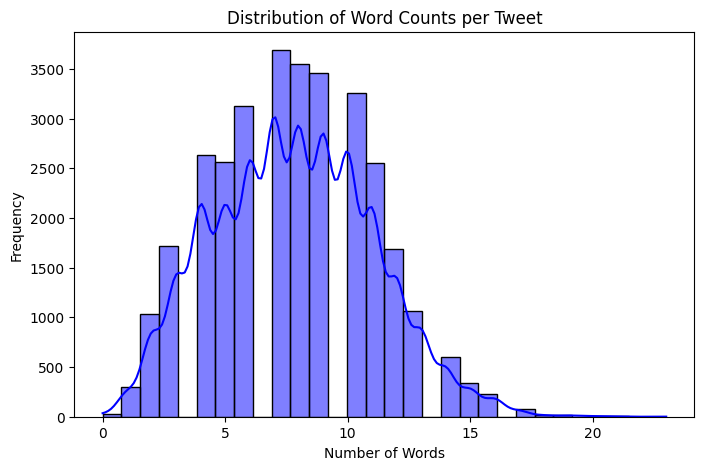

In [ ]:
# Add a column for number of words per tweet
df['word_count'] = df['lemmatized_tokens'].apply(len)

# Display distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=True, color='blue')
plt.title('Distribution of Word Counts per Tweet')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

### 5.2 Most Frequent Words in the Whole Dataset

We combine all lemmatized tokens and identify the top N most common words in the entire corpus.

/tmp/ipython-input-38-750994759.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


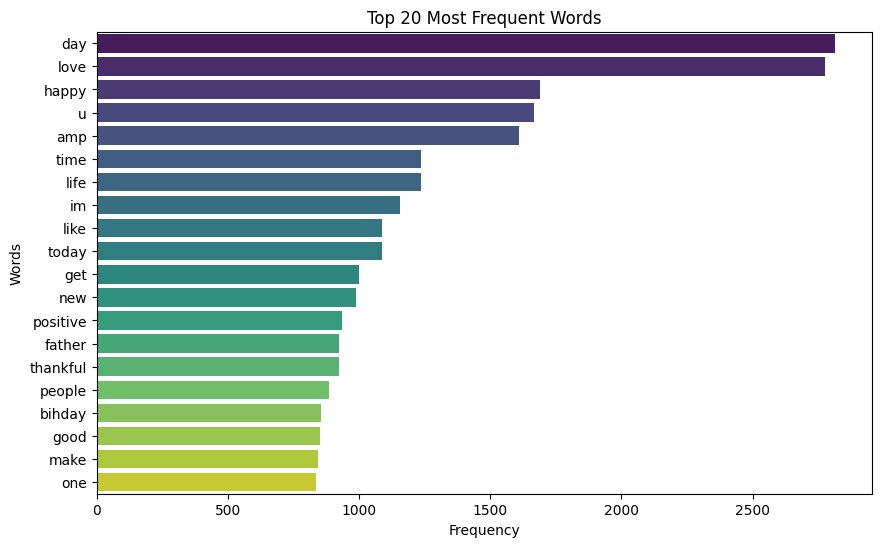

In [ ]:
from collections import Counter

# Flatten the list of tokens
all_words = [word for tokens in df['lemmatized_tokens'] for word in tokens]
word_freq = Counter(all_words)

# Show the 20 most common words
most_common_words = word_freq.most_common(20)

# Plot
words, counts = zip(*most_common_words)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

### 5.3 Most Frequent Words in Hate vs. Non-Hate Tweets
Separate the dataset into hate speech and non-hate speech tweets, then compute and compare frequent words.

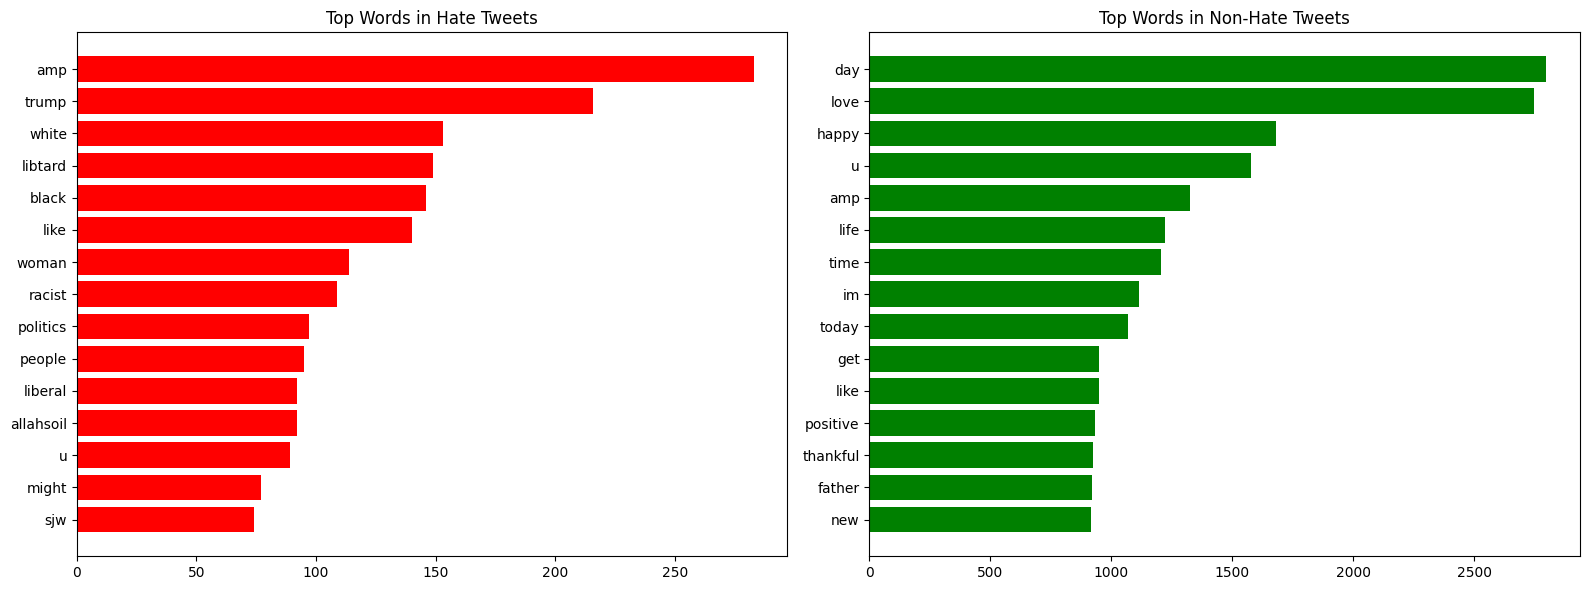

In [ ]:
hate_tweets = df[df['label'] == 1]
non_hate_tweets = df[df['label'] == 0]

# Get most frequent words for each category
hate_words = Counter([word for tokens in hate_tweets['lemmatized_tokens'] for word in tokens]).most_common(15)
non_hate_words = Counter([word for tokens in non_hate_tweets['lemmatized_tokens'] for word in tokens]).most_common(15)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(16,6))
axs[0].barh([w[0] for w in hate_words][::-1], [w[1] for w in hate_words][::-1], color='red')
axs[0].set_title("Top Words in Hate Tweets")
axs[1].barh([w[0] for w in non_hate_words][::-1], [w[1] for w in non_hate_words][::-1], color='green')
axs[1].set_title("Top Words in Non-Hate Tweets")
plt.tight_layout()
plt.show()


### 5.4 Word Cloud for Each Level
Visualize the most common words in a word cloud for hate and non-hate categories.

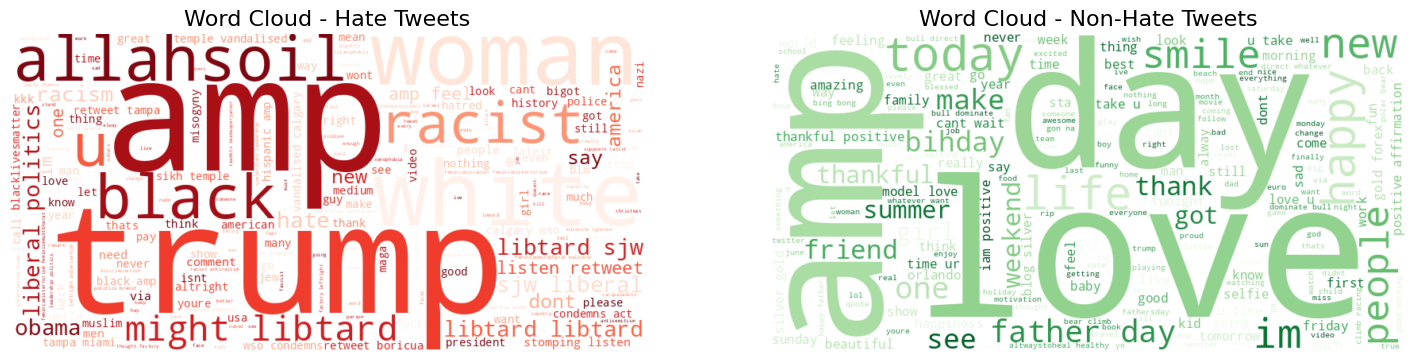

In [ ]:
from wordcloud import WordCloud

# Generate text for each category
hate_text = " ".join([" ".join(tokens) for tokens in hate_tweets['lemmatized_tokens']])
non_hate_text = " ".join([" ".join(tokens) for tokens in non_hate_tweets['lemmatized_tokens']])

# Create and display WordClouds
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

hate_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(hate_text)
non_hate_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(non_hate_text)

axs[0].imshow(hate_wc, interpolation='bilinear')
axs[0].set_title('Word Cloud - Hate Tweets', fontsize=16)
axs[0].axis('off')

axs[1].imshow(non_hate_wc, interpolation='bilinear')
axs[1].set_title('Word Cloud - Non-Hate Tweets', fontsize=16)
axs[1].axis('off')

plt.show()


### 5.5 Count of Hate Speech vs. Non-Hate Speech
Understand the distribution of hate and non-hate tweets in the dataset.

/tmp/ipython-input-41-1754198890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


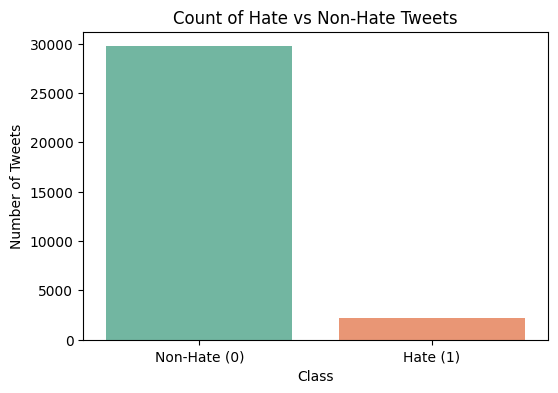

label
0    29720
1     2242
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.xticks([0,1], ['Non-Hate (0)', 'Hate (1)'])
plt.title("Count of Hate vs Non-Hate Tweets")
plt.ylabel("Number of Tweets")
plt.xlabel("Class")
plt.show()

print(df['label'].value_counts())

### 5.6 Solve the Imbalance Issue (Upsample Minority Class)

/tmp/ipython-input-42-1906374080.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_balanced, palette='coolwarm')


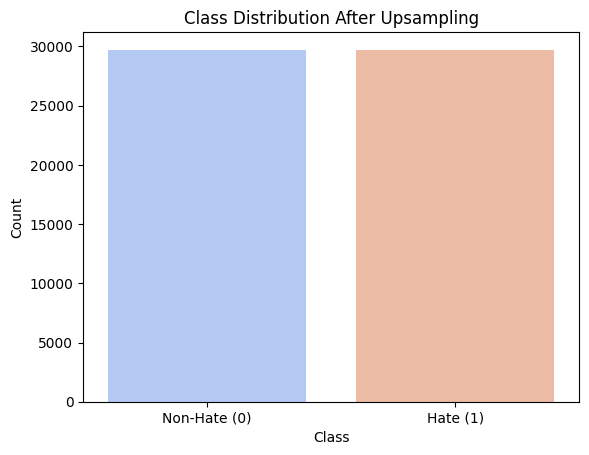

label
0    29720
1    29720
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

# Separate majority and minority classes
majority = df[df['label'] == df['label'].value_counts().idxmax()]
minority = df[df['label'] == df['label'].value_counts().idxmin()]

# Upsample minority
minority_upsampled = resample(minority,
                              replace=True,     # Sample with replacement
                              n_samples=len(majority),    # Match majority size
                              random_state=42)  # Reproducibility

# Combine and shuffle
df_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Show new distribution
sns.countplot(x='label', data=df_balanced, palette='coolwarm')
plt.title("Class Distribution After Upsampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ['Non-Hate (0)', 'Hate (1)'])
plt.show()

print(df_balanced['label'].value_counts())

## 6. Model Building and Training

In this section, we focus on building and training various machine learning and deep learning models for the classification of hate speech tweets. Based on the nature and complexity of the features and the capacity of the models, we have categorized them into traditional machine learning and deep learning models.

Feature Extraction Recap:
- TF-IDF: Used for SVM, Random Forest, XGBoost (traditional models)
- Word Embeddings: Used for CNN+LSTM
- BERT Embeddings: Used for Transformer (fine-tuning BERT)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse
import pickle

# Fit TF-IDF on the balanced dataset
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf_balanced = tfidf_vectorizer.fit_transform(df_balanced['text_cleaned'])

# Save TF-IDF features
scipy.sparse.save_npz("tfidf_features_balanced.npz", X_tfidf_balanced)

# ✅ Save vectorizer using pickle
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)


In [ ]:
import gensim.downloader as api
import numpy as np
import pickle

# Load GloVe embeddings (only once)
glove_vectors = api.load("glove-wiki-gigaword-100")

# Define average embedding function
def get_average_embedding(text, model, dim=100):
    tokens = text.split()
    valid_vectors = [model[word] for word in tokens if word in model]
    return np.mean(valid_vectors, axis=0) if valid_vectors else np.zeros(dim)

# Generate GloVe features
X_glove_balanced = np.vstack(df_balanced['text_cleaned'].apply(lambda x: get_average_embedding(x, glove_vectors)).values)

# Save features and GloVe model
np.save('glove_features_balanced.npy', X_glove_balanced)

with open("glove_vectors.pkl", "wb") as f:
    pickle.dump(glove_vectors, f)
# Double-check shape
print("GloVe Features (Balanced) Shape:", X_glove_balanced.shape)


GloVe Features (Balanced) Shape: (59440, 100)


In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from tqdm import tqdm

# Load BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

# Extract [CLS] token embeddings for BERT
def extract_bert_features(texts):
    features = []
    for text in tqdm(texts, desc="Extracting BERT features"):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        features.append(cls_embedding)
    return np.array(features)

# Generate and save BERT features
X_bert_balanced = extract_bert_features(df_balanced['text_cleaned'])
np.save('bert_features_balanced.npy', X_bert_balanced)
print("BERT Features (Balanced) Shape:", X_bert_balanced.shape)

Extracting BERT features: 100%|██████████| 59440/59440 [1:57:21<00:00,  8.44it/s]


BERT Features (Balanced) Shape: (59440, 768)


**Common Setup: Load and Split**

In [ ]:
import joblib  # For saving traditional ML models
import pickle  # Alternative for traditional models
from tensorflow.keras.models import load_model  # For deep learning models

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.sparse import load_npz
import numpy as np
import pandas as pd

# Labels
y_balanced = df_balanced['label']

# Load Features
X_tfidf_balanced = load_npz("tfidf_features_balanced.npz")
X_glove_balanced = np.load("glove_features_balanced.npy")
X_bert_balanced = np.load("bert_features_balanced.npy")

# Split Data
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf_balanced, y_balanced, test_size=0.2, random_state=42)
X_glove_train, X_glove_test, y_glove_train, y_glove_test = train_test_split(X_glove_balanced, y_balanced, test_size=0.2, random_state=42)
X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(X_bert_balanced, y_balanced, test_size=0.2, random_state=42)


### 6.1: SVM (TF-IDF)
Support Vector Machine is used here with TF-IDF features.
SVMs are powerful for high-dimensional sparse input and linear decision boundaries.

In [ ]:
from sklearn.svm import LinearSVC

def train_svm(X_train, y_train):
    model = LinearSVC()
    model.fit(X_train, y_train)
    joblib.dump(model, "svm_model.pkl")  # Save the model
    return model

svm_model = train_svm(X_tfidf_train, y_tfidf_train)

### 6.2: Random Forest (TF-IDF)
Random Forest is a robust ensemble model suitable for high-dimensional data.
It builds multiple trees and averages predictions to reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    joblib.dump(model, "rf_model.pkl")  # Save the model
    return model

rf_model = train_random_forest(X_tfidf_train, y_tfidf_train)

In [ ]:
import pickle
pickle.dump(rf_model, open("rf_model.pkl", "wb"))


### 6.3: XGBoost (TF-IDF)
XGBoost is a gradient boosting algorithm, highly effective in classification tasks.
It works well with sparse inputs like TF-IDF.

In [ ]:
import xgboost as xgb

def train_xgboost(X_train, y_train):
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    joblib.dump(model, "xgb_model.pkl")  # Save the model
    return model

xgb_model = train_xgboost(X_tfidf_train, y_tfidf_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:43:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### 6.4: CNN + LSTM (GloVe)
CNN captures local n-gram features, and LSTM captures temporal sequence.
Together with GloVe embeddings, this hybrid model performs well on text sequences.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Reshape

def train_cnn_lstm(X_train, y_train):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        Conv1D(64, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
    model.save("cnn_lstm_model.h5")  # Save the model
    return model

cnn_lstm_model = train_cnn_lstm(X_glove_train, y_glove_train)

Epoch 1/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.6038 - loss: 0.6474 - val_accuracy: 0.7657 - val_loss: 0.4950
Epoch 2/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.7745 - loss: 0.4824 - val_accuracy: 0.7951 - val_loss: 0.4469
Epoch 3/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.7977 - loss: 0.4464 - val_accuracy: 0.8020 - val_loss: 0.4350
Epoch 4/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.8032 - loss: 0.4297 - val_accuracy: 0.8127 - val_loss: 0.4087
Epoch 5/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.8197 - loss: 0.4138 - val_accuracy: 0.8203 - val_loss: 0.4046


### 6.5: Transformer (BERT Features)

A transformer-style dense network fine-tuned on BERT embeddings.
BERT provides rich semantic representations useful for binary classification.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input

def train_bert_dense(X_train, y_train):
    inputs = Input(shape=(X_train.shape[1],))
    x = Dense(256, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, output)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
    model.save("bert_dense_model.h5")  # Save the model
    return model

bert_dense_model = train_bert_dense(X_bert_train, y_bert_train)

Epoch 1/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8051 - loss: 0.4185 - val_accuracy: 0.8757 - val_loss: 0.2914
Epoch 2/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8819 - loss: 0.2869 - val_accuracy: 0.8978 - val_loss: 0.2466
Epoch 3/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9068 - loss: 0.2300 - val_accuracy: 0.9260 - val_loss: 0.1902
Epoch 4/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9244 - loss: 0.1906 - val_accuracy: 0.9372 - val_loss: 0.1663
Epoch 5/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9332 - loss: 0.1665 - val_accuracy: 0.9496 - val_loss: 0.1372


## 7. Model Performance Evaluation
In this section, we evaluate the trained models using several key metrics. For each model, we compute and visualize the confusion matrix, generate a classification report, calculate the ROC-AUC score, and plot the ROC curve. These evaluations will help us understand model performance beyond simple accuracy by focusing on precision, recall, F1-score, and discriminatory capability.

### 7.1 Confusion Matrix
We compute and visualize confusion matrices for all five models to examine how well they distinguish between the hate and non-hate classes.

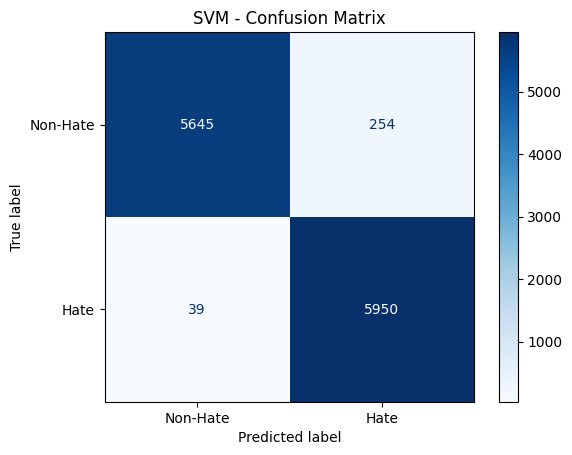

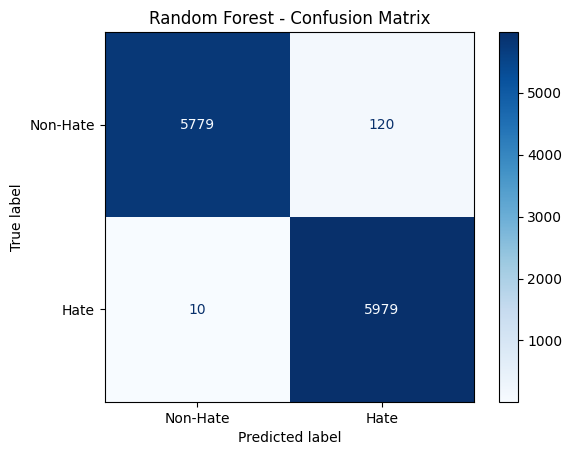

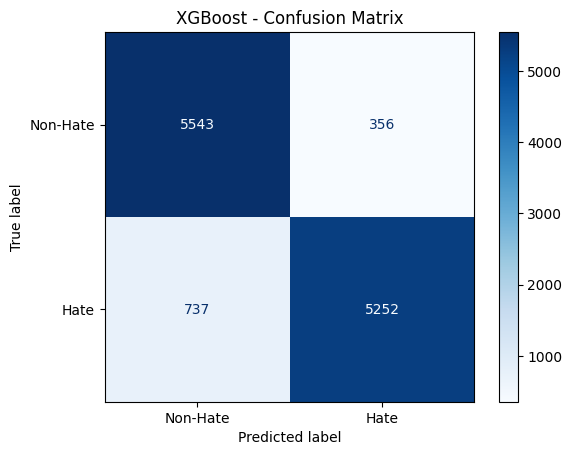

372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


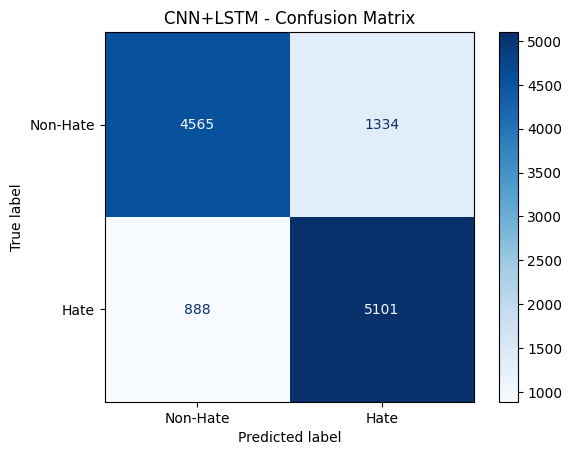

372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


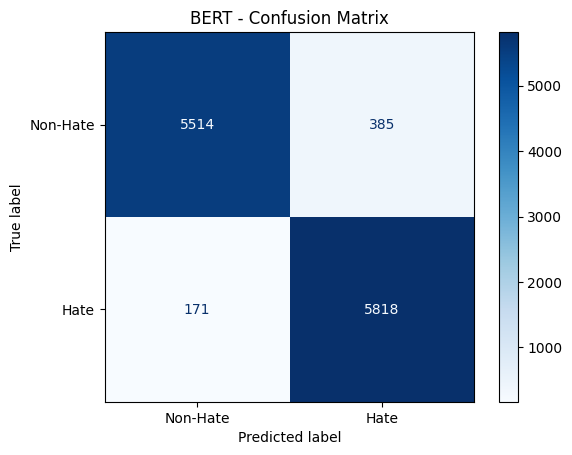

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_conf_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    if hasattr(y_pred, "toarray"): y_pred = y_pred.toarray()
    if hasattr(y_pred[0], "__len__") and len(y_pred[0]) == 1:  # for DL models
        y_pred = (y_pred > 0.5).astype(int).flatten()
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hate', 'Hate'])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Traditional Models (TF-IDF)
plot_conf_matrix(svm_model, X_tfidf_test, y_tfidf_test, "SVM - Confusion Matrix")
plot_conf_matrix(rf_model, X_tfidf_test, y_tfidf_test, "Random Forest - Confusion Matrix")
plot_conf_matrix(xgb_model, X_tfidf_test, y_tfidf_test, "XGBoost - Confusion Matrix")

# Deep Models
plot_conf_matrix(cnn_lstm_model, X_glove_test, y_glove_test, "CNN+LSTM - Confusion Matrix")
plot_conf_matrix(bert_dense_model, X_bert_test, y_bert_test, "BERT - Confusion Matrix")


### 7.2 Classification Report
We generate detailed classification reports showing precision, recall, F1-score, and support for both classes.

In [ ]:
from sklearn.metrics import classification_report

def report_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    if hasattr(y_pred, "toarray"): y_pred = y_pred.toarray()
    if hasattr(y_pred[0], "__len__") and len(y_pred[0]) == 1:
        y_pred = (y_pred > 0.5).astype(int).flatten()
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred, target_names=["Non-Hate", "Hate"]))

# Generate reports
report_metrics(svm_model, X_tfidf_test, y_tfidf_test, "SVM")
report_metrics(rf_model, X_tfidf_test, y_tfidf_test, "Random Forest")
report_metrics(xgb_model, X_tfidf_test, y_tfidf_test, "XGBoost")
report_metrics(cnn_lstm_model, X_glove_test, y_glove_test, "CNN+LSTM")
report_metrics(bert_dense_model, X_bert_test, y_bert_test, "BERT")



Classification Report for SVM:

              precision    recall  f1-score   support

    Non-Hate       0.99      0.96      0.97      5899
        Hate       0.96      0.99      0.98      5989

    accuracy                           0.98     11888
   macro avg       0.98      0.98      0.98     11888
weighted avg       0.98      0.98      0.98     11888


Classification Report for Random Forest:

              precision    recall  f1-score   support

    Non-Hate       1.00      0.98      0.99      5899
        Hate       0.98      1.00      0.99      5989

    accuracy                           0.99     11888
   macro avg       0.99      0.99      0.99     11888
weighted avg       0.99      0.99      0.99     11888


Classification Report for XGBoost:

              precision    recall  f1-score   support

    Non-Hate       0.88      0.94      0.91      5899
        Hate       0.94      0.88      0.91      5989

    accuracy                           0.91     11888
   macro avg   

From the confusion matrix and classification report, all five models we used perform very well. The Random Forest has the highest accuracy (99%), while the CNN+LSTM has the lowest accuracy (81%).

The Random Forest performs best on predicting both hate and non-hate tweets.

### 7.3 ROC-AUC Score
We compute ROC-AUC scores to assess how well each model distinguishes between the classes.

In [ ]:
from sklearn.metrics import roc_auc_score

def calculate_auc(model, X_test, y_test, name):
    y_proba = model.predict(X_test)
    if hasattr(y_proba[0], "__len__") and len(y_proba[0]) == 1:
        y_proba = y_proba.flatten()
    score = roc_auc_score(y_test, y_proba)
    print(f"{name} ROC-AUC Score: {score:.4f}")

calculate_auc(svm_model, X_tfidf_test, y_tfidf_test, "SVM")
calculate_auc(rf_model, X_tfidf_test, y_tfidf_test, "Random Forest")
calculate_auc(xgb_model, X_tfidf_test, y_tfidf_test, "XGBoost")
calculate_auc(cnn_lstm_model, X_glove_test, y_glove_test, "CNN+LSTM")
calculate_auc(bert_dense_model, X_bert_test, y_bert_test, "BERT")


SVM ROC-AUC Score: 0.9752
Random Forest ROC-AUC Score: 0.9890
XGBoost ROC-AUC Score: 0.9083
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
CNN+LSTM ROC-AUC Score: 0.8930
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
BERT ROC-AUC Score: 0.9850


The Random Forest model has the highest ROC-AUC score, which means that it has the best overall performance and discrimination capability of all five models we used.

### 7.4 ROC Curve
We visualize the ROC curve for each model to analyze their sensitivity-specificity trade-offs.

372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


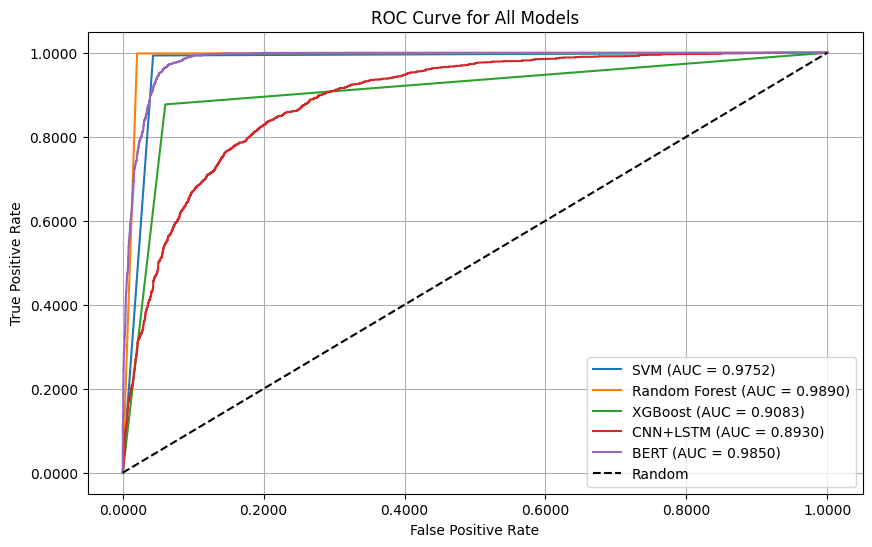

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.ticker import FormatStrFormatter

def plot_roc(model, X_test, y_test, name):
    y_score = model.predict(X_test)
    if hasattr(y_score[0], "__len__") and len(y_score[0]) == 1:
        y_score = y_score.flatten()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.figure(figsize=(10, 6))

# Plot all models
plot_roc(svm_model, X_tfidf_test, y_tfidf_test, "SVM")
plot_roc(rf_model, X_tfidf_test, y_tfidf_test, "Random Forest")
plot_roc(xgb_model, X_tfidf_test, y_tfidf_test, "XGBoost")
plot_roc(cnn_lstm_model, X_glove_test, y_glove_test, "CNN+LSTM")
plot_roc(bert_dense_model, X_bert_test, y_bert_test, "BERT")

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random")

# Axis formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for All Models')
plt.legend(loc='lower right')
plt.grid(True)

# Format tick labels to 4 decimal places
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.show()

From the plot, the Random Forest model has the highest AUC (area under the curve). It is the orange line, which is overlapped with purple line and blue line. This model has the best ability to distinguish between hate and non-hate tweets across different threshold settings.

## 8.Make a Prediction

### 8.1 Load Model and Vectorizer

In [ ]:
import joblib

# Load saved Random Forest model and TF-IDF vectorizer
rf_model = joblib.load("rf_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")


### 8.2 Predict on a Hate Tweet

In [ ]:
# Example of a hate tweet
hate_tweet = "I support white supremacy, white people should rule the world"

# Vectorize and predict
vec_hate = tfidf_vectorizer.transform([hate_tweet])
pred_hate = rf_model.predict(vec_hate)[0]

print("Prediction:", "HATE" if pred_hate == 1 else "NON-HATE")


Prediction: HATE


### 8.3 Predict on a Non-Hate Tweet

In [ ]:
# Example of a non-hate tweet
non_hate_tweet = "Had a fantastic day volunteering at the local animal shelter!"

# Vectorize and predict
vec_non_hate = tfidf_vectorizer.transform([non_hate_tweet])
pred_non_hate = rf_model.predict(vec_non_hate)[0]

print("Prediction:", "HATE" if pred_non_hate == 1 else "NON-HATE")


Prediction: NON-HATE
